In [1]:
from pybaseball import playerid_lookup

info = playerid_lookup("matsui", "yuki", fuzzy=True)
print(info[["name_first", "name_last", "key_mlbam", "mlb_played_first", "mlb_played_last"]])


Gathering player lookup table. This may take a moment.
  name_first name_last  key_mlbam  mlb_played_first  mlb_played_last
0       yuki    matsui     673513            2024.0           2026.0


In [2]:
from pybaseball import playerid_lookup

info = playerid_lookup("matsui", "yuki", fuzzy=True)
print(info[["name_first", "name_last", "key_mlbam", "mlb_played_first", "mlb_played_last"]])

  name_first name_last  key_mlbam  mlb_played_first  mlb_played_last
0       yuki    matsui     673513            2024.0           2026.0


In [3]:
pid = int(info.iloc[0]["key_mlbam"])
print("Using ID:", pid)


Using ID: 673513


In [4]:
import pandas as pd
from pybaseball import statcast_pitcher

pulls = {"2025": ("2025-03-01","2025-11-01"),
         "2026": ("2026-03-01","2026-08-09")}

frames = []
for label,(s,e) in pulls.items():
    df = statcast_pitcher(s, e, pid)
    if df is not None and len(df) > 0:
        df["season"] = label
        frames.append(df)
        print(label, "->", len(df), "pitches")

matsui = pd.concat(frames, ignore_index=True)
print("done")

Gathering Player Data
2025 -> 1174 pitches
Gathering Player Data
2026 -> 747 pitches
done


In [5]:
print(matsui.groupby(['season','pitch_type']).size().unstack(fill_value=0))

pitch_type  CU   FF   FS  SI   SL   ST
season                                
2025         2  463  364  23  178  130
2026         0  278  188  20  222   30


In [6]:
print(matsui.groupby(['season','pitch_type'])['release_speed'].mean().unstack())
print(matsui.groupby(['season','pitch_type'])['release_spin_rate'].mean().unstack())

pitch_type    CU         FF         FS         SI         SL         ST
season                                                                 
2025        74.8  92.033045  83.972253  91.356522  86.598876  81.325385
2026         NaN  91.910791  83.313830  90.970000  85.254505  81.100000
pitch_type      CU           FF           FS      SI           SL           ST
season                                                                        
2025        2679.0  2435.207343  1165.717033  2197.0  2650.803371  2866.423077
2026           NaN  2437.043165  1139.340426  2099.0  2700.382883  2879.866667


In [7]:
swings = matsui[matsui['description'].isin(['swinging_strike','swinging_strike_blocked','foul','foul_tip','hit_into_play'])]
whiffs = matsui[matsui['description'].isin(['swinging_strike','swinging_strike_blocked'])]
whiff_rate = whiffs.groupby(['season','pitch_type']).size() / swings.groupby(['season','pitch_type']).size()
print("Whiff rate:\n", whiff_rate.unstack())

outside = matsui[matsui['zone'] > 9]
chase_swings = outside[outside['description'].isin(['swinging_strike','swinging_strike_blocked','foul','foul_tip','hit_into_play'])]
chase_rate = chase_swings.groupby(['season','pitch_type']).size() / outside.groupby(['season','pitch_type']).size()
print("Chase rate:\n", chase_rate.unstack())

Whiff rate:
 pitch_type   CU       FF        FS        SI        SL        ST
season                                                          
2025        0.5  0.15812  0.425000  0.181818  0.240964  0.444444
2026        NaN  0.20000  0.471698       NaN  0.380435  0.300000
Chase rate:
 pitch_type   CU        FF        FS        SI        SL        ST
season                                                           
2025        1.0  0.242718  0.390756  0.444444  0.187500  0.271605
2026        NaN  0.253846  0.481481  0.200000  0.239669  0.125000


In [9]:
from pybaseball import pitching_stats_bref

br_2025 = pitching_stats_bref(2025)
br_2026 = pitching_stats_bref(2026)

b25 = br_2025[br_2025['Name'].str.contains('Matsui', na=False)]
b26 = br_2026[br_2026['Name'].str.contains('Matsui', na=False)]

cols = ['Name','ERA','IP','SO','BB','HBP','HR']
compare = pd.concat([b25[cols], b26[cols]])
print(compare)

            Name   ERA    IP  SO  BB  HBP  HR
493  Yuki Matsui  3.98  63.1  61  33    1  10
447  Yuki Matsui  2.40  45.0  47  26    2   6


In [ ]:
2025:
      last_name, first_name  player_id team_name_alt pitch_type  \
516           Matsui, Yuki     673513            SD         FF   
543           Matsui, Yuki     673513            SD         FS   
1506          Matsui, Yuki     673513            SD         SL   
2037          Matsui, Yuki     673513            SD         ST   
3264          Matsui, Yuki     673513            SD         SI   

           pitch_name  run_value_per_100  run_value  pitches  pitch_usage  \
516   4-Seam Fastball               -1.1         -5      420         39.5   
543      Split-Finger               -0.2         -1      342         32.2   
1506           Slider                1.0          2      169         15.9   
2037          Sweeper                1.7          2      114         10.7   
3264           Sinker               -3.8         -1       16          1.5   

       pa     ba    slg   woba  whiff_percent  k_percent  put_away  est_ba  \
516   105  0.235  0.529  0.393           17.9       14.3      15.6   0.231   
543   102  0.223  0.394  0.290           44.9       35.3      26.5   0.194   
1506   38  0.273  0.364  0.285           22.8        5.3       8.0   0.322   
2037   22  0.056  0.056  0.168           43.6       36.4      23.5   0.162   
3264    3  0.667  0.667  0.600           22.2        0.0       0.0   0.517   

      est_slg  est_woba  hard_hit_percent  
516     0.486     0.369              46.5  
543     0.311     0.248              32.2  
1506    0.458     0.342              38.2  
2037    0.282     0.282              10.0  
3264    0.590     0.495               0.0  

2026:
      last_name, first_name  player_id team_name_alt pitch_type  \
641           Matsui, Yuki     673513            SD         FF   
864           Matsui, Yuki     673513            SD         FS   
983           Matsui, Yuki     673513            SD         SL   
2617          Matsui, Yuki     673513            SD         SI   
2754          Matsui, Yuki     673513            SD         ST   

           pitch_name  run_value_per_100  run_value  pitches  pitch_usage  pa  \
641   4-Seam Fastball               -0.6         -2      278         37.7  69   
864      Split-Finger                0.1          0      188         25.5  54   
983            Slider                2.9          6      222         30.1  48   
2617           Sinker                0.5          0       20          2.7   6   
2754          Sweeper               -3.0         -1       30          4.1   5   

         ba    slg   woba  whiff_percent  k_percent  put_away  est_ba  \
641   0.283  0.528  0.393           25.2       17.4      16.4   0.215   
864   0.152  0.326  0.248           48.1       37.0      21.5   0.143   
983   0.093  0.116  0.141           40.9       25.0      28.6   0.149   
2617  0.000  0.000  0.233            0.0        0.0       0.0   0.141   
2754  0.200  0.800  0.400           30.0       60.0      18.8   0.238   

      est_slg  est_woba  hard_hit_percent  
641     0.428     0.364              44.2  
864     0.284     0.241              25.0  
983     0.250     0.215              18.8  
2617    0.163     0.321               0.0  
2754    0.668     0.376             100.0  


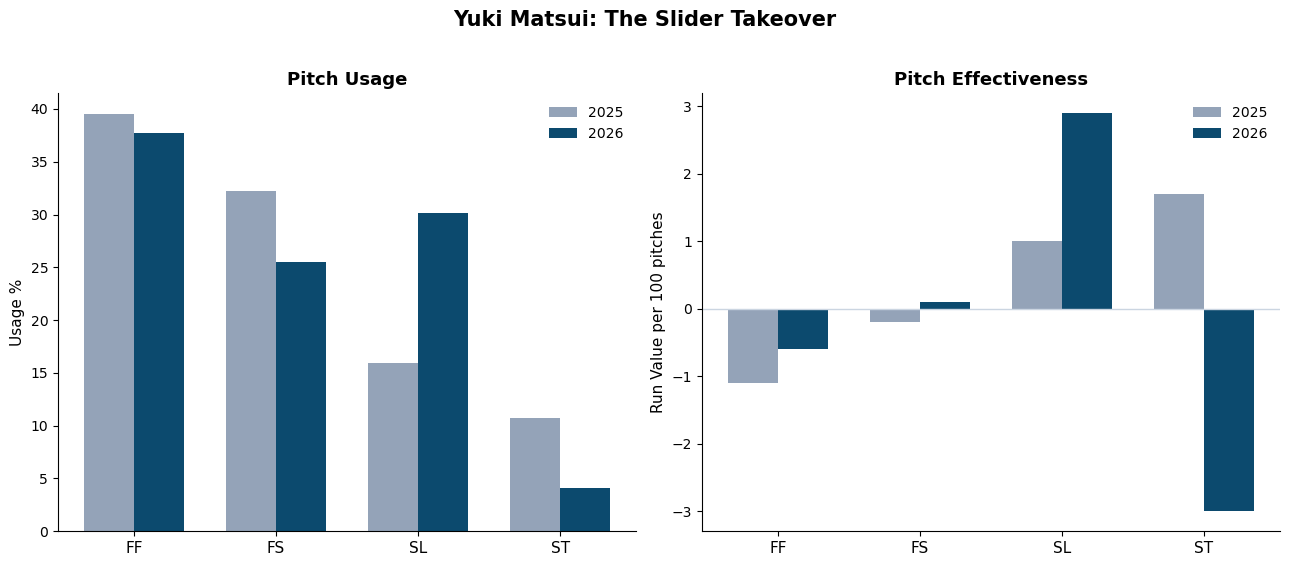

In [16]:
import matplotlib.pyplot as plt
import numpy as np

pitches = ['FF', 'FS', 'SL', 'ST']
usage_2025 = [39.5, 32.2, 15.9, 10.7]
usage_2026 = [37.7, 25.5, 30.1, 4.1]
rv_2025 = [-1.1, -0.2, 1.0, 1.7]
rv_2026 = [-0.6, 0.1, 2.9, -3.0]

x = np.arange(len(pitches))
width = 0.35

gray = '#94a3b8'
navy = '#0c4a6e'

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5.5))
fig.patch.set_facecolor('white')

ax1.bar(x - width/2, usage_2025, width, label='2025', color=gray)
ax1.bar(x + width/2, usage_2026, width, label='2026', color=navy)
ax1.set_ylabel('Usage %', fontsize=11)
ax1.set_title('Pitch Usage', fontsize=13, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(pitches, fontsize=11)
ax1.legend(frameon=False)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

ax2.axhline(0, color='#cbd5e1', linewidth=1)
ax2.bar(x - width/2, rv_2025, width, label='2025', color=gray)
ax2.bar(x + width/2, rv_2026, width, label='2026', color=navy)
ax2.set_ylabel('Run Value per 100 pitches', fontsize=11)
ax2.set_title('Pitch Effectiveness', fontsize=13, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(pitches, fontsize=11)
ax2.legend(frameon=False)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

fig.suptitle('Yuki Matsui: The Slider Takeover', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('matsui_slider_chart.png', dpi=200, bbox_inches='tight')
plt.show()

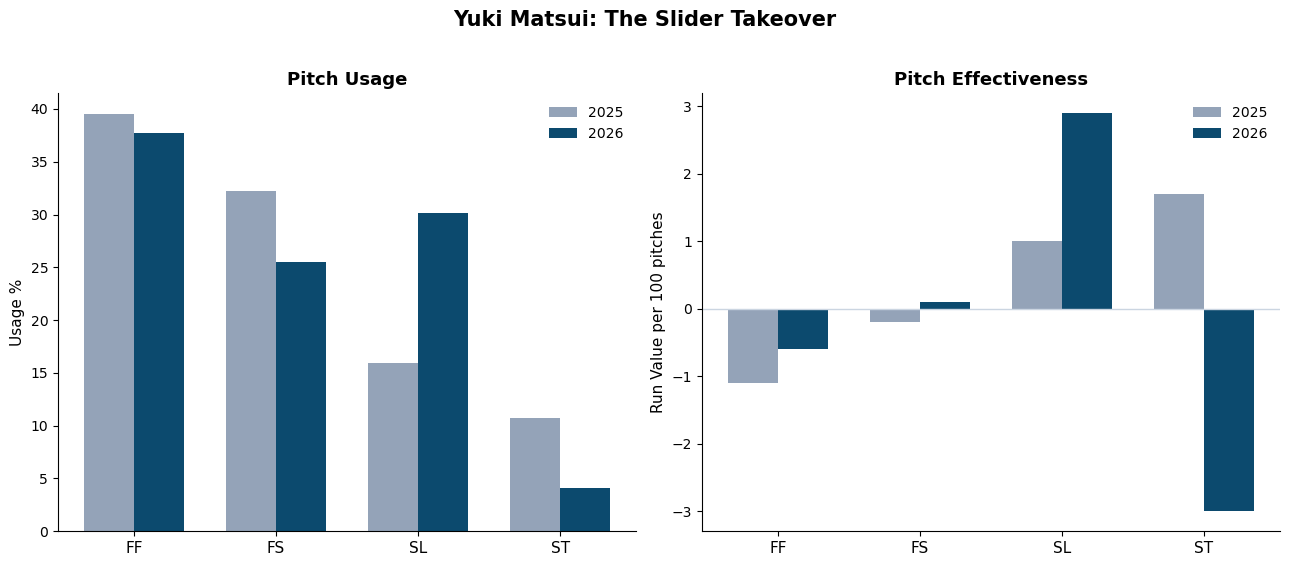

In [17]:
import matplotlib.pyplot as plt
import numpy as np

order = ['FF', 'FS', 'SL', 'ST']

u25 = a25.set_index('pitch_type').reindex(order)['pitch_usage']
u26 = a26.set_index('pitch_type').reindex(order)['pitch_usage']
rv25 = a25.set_index('pitch_type').reindex(order)['run_value_per_100']
rv26 = a26.set_index('pitch_type').reindex(order)['run_value_per_100']

x = np.arange(len(order))
width = 0.35

gray = '#94a3b8'
navy = '#0c4a6e'

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5.5))
fig.patch.set_facecolor('white')

ax1.bar(x - width/2, u25, width, label='2025', color=gray)
ax1.bar(x + width/2, u26, width, label='2026', color=navy)
ax1.set_ylabel('Usage %', fontsize=11)
ax1.set_title('Pitch Usage', fontsize=13, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(order, fontsize=11)
ax1.legend(frameon=False)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

ax2.axhline(0, color='#cbd5e1', linewidth=1)
ax2.bar(x - width/2, rv25, width, label='2025', color=gray)
ax2.bar(x + width/2, rv26, width, label='2026', color=navy)
ax2.set_ylabel('Run Value per 100 pitches', fontsize=11)
ax2.set_title('Pitch Effectiveness', fontsize=13, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(order, fontsize=11)
ax2.legend(frameon=False)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

fig.suptitle('Yuki Matsui: The Slider Takeover', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('matsui_slider_chart.png', dpi=200, bbox_inches='tight')
plt.show()

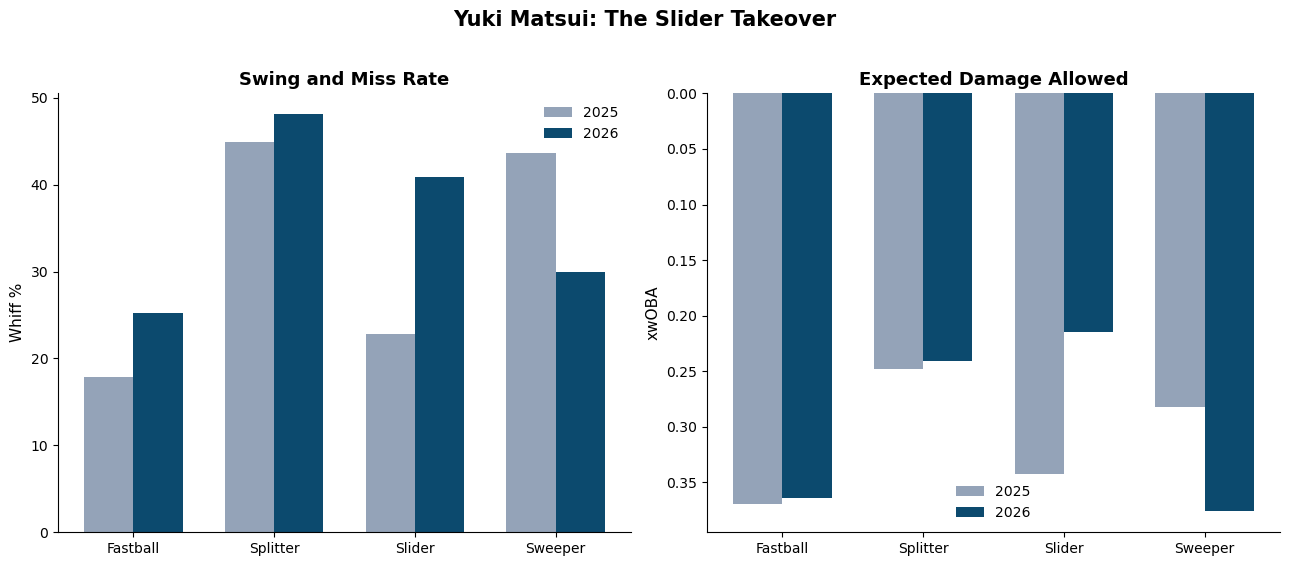

In [18]:
import matplotlib.pyplot as plt
import numpy as np

order = ['FF', 'FS', 'SL', 'ST']
labels = ['Fastball', 'Splitter', 'Slider', 'Sweeper']

whiff25 = a25.set_index('pitch_type').reindex(order)['whiff_percent']
whiff26 = a26.set_index('pitch_type').reindex(order)['whiff_percent']
xwoba25 = a25.set_index('pitch_type').reindex(order)['est_woba']
xwoba26 = a26.set_index('pitch_type').reindex(order)['est_woba']

x = np.arange(len(order))
width = 0.35
gray = '#94a3b8'
navy = '#0c4a6e'

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5.5))
fig.patch.set_facecolor('white')

ax1.bar(x - width/2, whiff25, width, label='2025', color=gray)
ax1.bar(x + width/2, whiff26, width, label='2026', color=navy)
ax1.set_ylabel('Whiff %', fontsize=11)
ax1.set_title('Swing and Miss Rate', fontsize=13, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(labels, fontsize=10)
ax1.legend(frameon=False)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

ax2.bar(x - width/2, xwoba25, width, label='2025', color=gray)
ax2.bar(x + width/2, xwoba26, width, label='2026', color=navy)
ax2.set_ylabel('xwOBA', fontsize=11)
ax2.set_title('Expected Damage Allowed', fontsize=13, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(labels, fontsize=10)
ax2.legend(frameon=False)
ax2.invert_yaxis()
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

fig.suptitle('Yuki Matsui: The Slider Takeover', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('matsui_slider_chart.png', dpi=200, bbox_inches='tight')
plt.show()

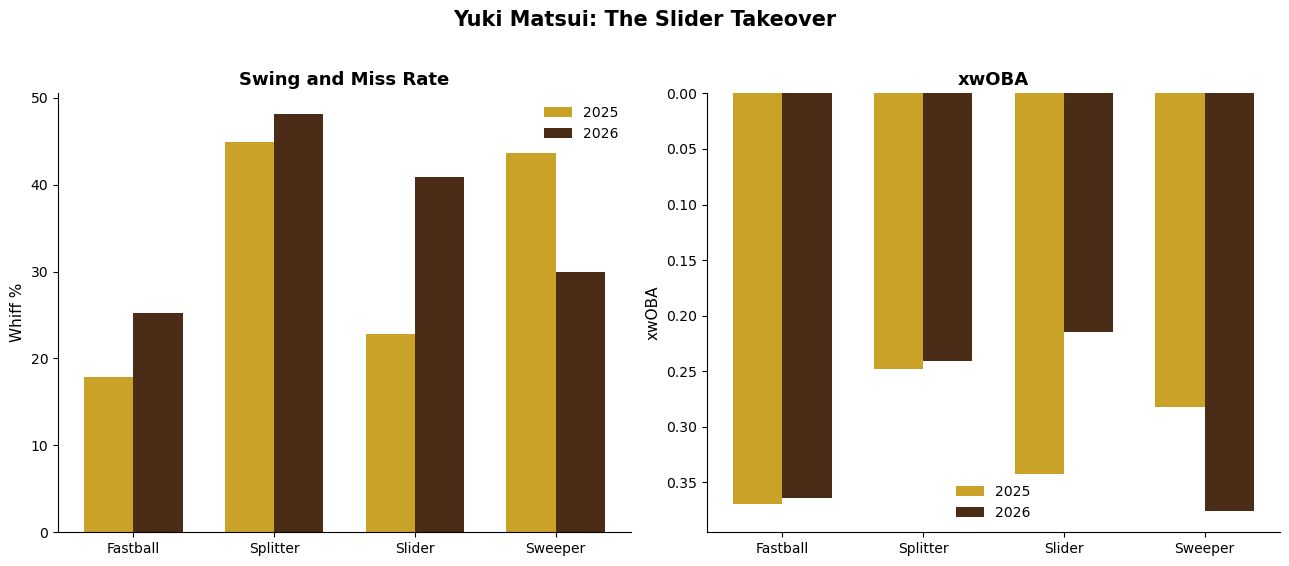

In [19]:
import matplotlib.pyplot as plt
import numpy as np

order = ['FF', 'FS', 'SL', 'ST']
labels = ['Fastball', 'Splitter', 'Slider', 'Sweeper']

whiff25 = a25.set_index('pitch_type').reindex(order)['whiff_percent']
whiff26 = a26.set_index('pitch_type').reindex(order)['whiff_percent']
xwoba25 = a25.set_index('pitch_type').reindex(order)['est_woba']
xwoba26 = a26.set_index('pitch_type').reindex(order)['est_woba']

x = np.arange(len(order))
width = 0.35
gold = '#c9a227'
brown = '#4a2c17'

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5.5))
fig.patch.set_facecolor('white')

ax1.bar(x - width/2, whiff25, width, label='2025', color=gold)
ax1.bar(x + width/2, whiff26, width, label='2026', color=brown)
ax1.set_ylabel('Whiff %', fontsize=11)
ax1.set_title('Swing and Miss Rate', fontsize=13, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(labels, fontsize=10)
ax1.legend(frameon=False)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

ax2.bar(x - width/2, xwoba25, width, label='2025', color=gold)
ax2.bar(x + width/2, xwoba26, width, label='2026', color=brown)
ax2.set_ylabel('xwOBA', fontsize=11)
ax2.set_title('xwOBA', fontsize=13, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(labels, fontsize=10)
ax2.legend(frameon=False)
ax2.invert_yaxis()
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

fig.suptitle('Yuki Matsui: The Slider Takeover', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('matsui_slider_chart.png', dpi=200, bbox_inches='tight')
plt.show()

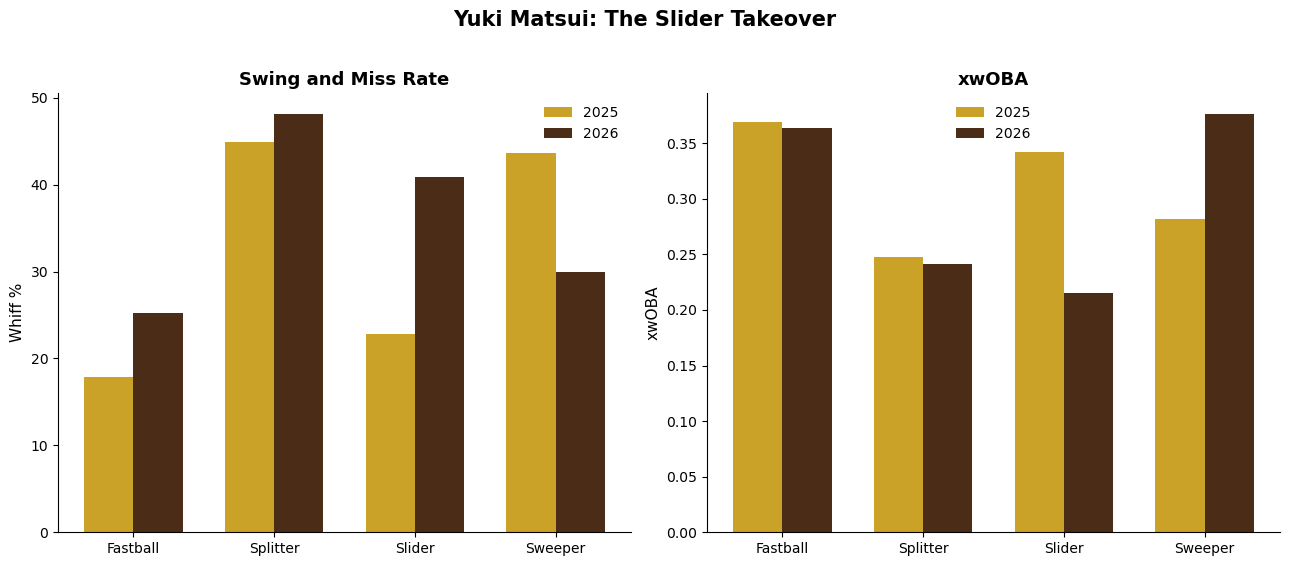

In [22]:
import matplotlib.pyplot as plt
import numpy as np

order = ['FF', 'FS', 'SL', 'ST']
labels = ['Fastball', 'Splitter', 'Slider', 'Sweeper']

whiff25 = a25.set_index('pitch_type').reindex(order)['whiff_percent']
whiff26 = a26.set_index('pitch_type').reindex(order)['whiff_percent']
xwoba25 = a25.set_index('pitch_type').reindex(order)['est_woba']
xwoba26 = a26.set_index('pitch_type').reindex(order)['est_woba']

x = np.arange(len(order))
width = 0.35
gold = '#c9a227'
brown = '#4a2c17'

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5.5))
fig.patch.set_facecolor('white')

ax1.bar(x - width/2, whiff25, width, label='2025', color=gold)
ax1.bar(x + width/2, whiff26, width, label='2026', color=brown)
ax1.set_ylabel('Whiff %', fontsize=11)
ax1.set_title('Swing and Miss Rate', fontsize=13, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(labels, fontsize=10)
ax1.legend(frameon=False)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

ax2.bar(x - width/2, xwoba25, width, label='2025', color=gold)
ax2.bar(x + width/2, xwoba26, width, label='2026', color=brown)
ax2.set_ylabel('xwOBA', fontsize=11)
ax2.set_title('xwOBA', fontsize=13, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(labels, fontsize=10)
ax2.legend(frameon=False)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

fig.suptitle('Yuki Matsui: The Slider Takeover', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('matsui_slider_chart.png', dpi=200, bbox_inches='tight')
plt.show()

In [23]:
print([c for c in matsui.columns if 'arm' in c.lower() or 'release' in c.lower()])

['release_speed', 'release_pos_x', 'release_pos_z', 'release_spin_rate', 'release_extension', 'release_pos_y', 'api_break_x_arm', 'arm_angle']


In [24]:
print("Arm angle by season:")
print(matsui.groupby('season')['arm_angle'].mean())

print("\nArm angle by season/pitch:")
print(matsui.groupby(['season','pitch_type'])['arm_angle'].mean().unstack())

print("\nRelease extension by season:")
print(matsui.groupby('season')['release_extension'].mean())

print("\nRelease position (x, z) by season:")
print(matsui.groupby('season')[['release_pos_x','release_pos_z']].mean())

Arm angle by season:
season
2025    54.868109
2026    54.226152
Name: arm_angle, dtype: float64

Arm angle by season/pitch:
pitch_type    CU         FF         FS      SI         SL         ST
season                                                              
2025        64.1  55.137619  54.921345  52.175  54.240237  54.862281
2026         NaN  54.489568  54.185106  54.400  54.003153  53.576667

Release extension by season:
season
2025    5.828966
2026    5.791057
Name: release_extension, dtype: float64

Release position (x, z) by season:
        release_pos_x  release_pos_z
season                              
2025         2.022017       6.064302
2026         1.918428       6.090190


In [25]:
print(matsui[matsui['pitch_type']=='SL'].groupby('season')[['release_speed','release_spin_rate','pfx_x','pfx_z','api_break_x_arm']].mean())

        release_speed  release_spin_rate     pfx_x     pfx_z  api_break_x_arm
season                                                                       
2025        86.598876        2650.803371 -0.243427  0.573708        -0.243427
2026        85.254505        2700.382883 -0.354459  0.323018        -0.354459


In [26]:
print([c for c in matsui.columns if 'axis' in c.lower() or 'spin_dir' in c.lower()])

['spin_dir', 'spin_axis']


In [27]:
print(matsui[matsui['pitch_type']=='SL'].groupby('season')['spin_axis'].mean())

season
2025    191.157303
2026    217.689189
Name: spin_axis, dtype: float64
